In [1]:
# Import the database connection tool and data processing tool of Words
import wrds
import pandas as pd
# Configure a personal Wrds account and establish a remote database connection
username="yourusername"
db=wrds.Connection(wrds_username="username")

Enter your WRDS username [username]: fangbo
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  y


pgpass file created at C:\Users\Administrator\AppData\Roaming\postgresql\pgpass.conf
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


In [2]:
# Write an SQL statement to retrieve the historical financial panel data of Moutai.
data=db.raw_sql("""
SELECT stkcd, accper, typrep, a001000000, a002000000, a003000000,b001101000,b001201000,c001000000
FROM csmar.wrds_csmar_financial_master
WHERE stkcd='600519'
AND typrep='A'
AND a001000000 > 0
LIMIT 500
""")
# View the query result table
data

,stkcd,accper,typrep,a001000000,a002000000,a003000000,b001101000,b001201000,c001000000
0,600519,2017-12-31,A,134610116875.080002,38590489400.0,96019627475.080002,58217861314.169998,5940436371.97,22153036084.130001
1,600519,2018-01-01,A,134610116875.080002,38590489400.0,96019627475.080002,58217861314.169998,5940436371.97,22153036084.130001
2,600519,2018-03-31,A,134404941948.300003,29255260792.919998,105149681155.380005,17466166384.959999,1518592897.51,4935500707.47
3,600519,2018-06-30,A,129914832498.210007,33410357927.630001,96504474570.580002,33396709893.110001,3025025121.38,17735030962.189999
4,600519,2018-09-30,A,147147672376.160004,40990610327.230003,106157062048.929993,52241669986.010002,4637055449.21,28221285915.540001
...,...,...,...,...,...,...,...,...,...
113,600519,2024-01-01,A,272699660092.25,49043190797.43,223656469294.820007,147693604994.140015,11867273851.780001,66593247721.089996
114,600519,2024-03-31,A,285524543268.380005,36987774717.849998,248536768550.529999,45775517043.290001,3381292339.02,9187422415.09
115,600519,2024-06-30,A,279207261166.630005,51162451517.349998,228044809649.279999,81930977667.75,6750879251.19,36621833812.629997
116,600519,2024-09-30,A,286770722957.690002,39082558719.519997,247688164238.170013,120776131874.690002,10228077394.34,44421386217.449997


In [3]:
# Export the extracted financial data of Moutai into a CSV file to facilitate subsequent analysis. Set index=False to not include row indices, and use utf-8-sig encoding to ensure no garbled characters when opening in Excel.
data.to_csv("csmar_track2_data.csv",index=False,encoding="utf-8-sig")

In [4]:
db.close()

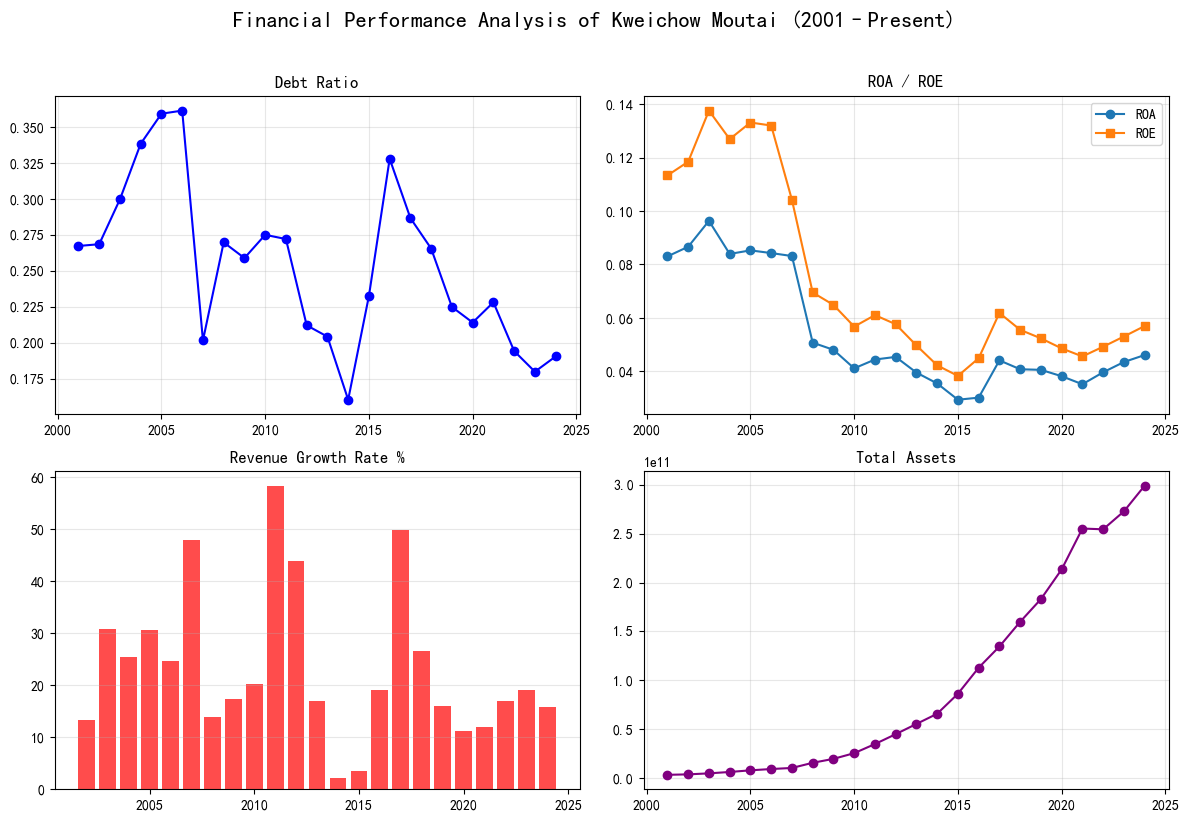

In [5]:
# Import the data analysis library pandas and the plotting library matplotlib
import pandas as pd
import matplotlib.pyplot as plt
# Set the font for the chart to prevent Chinese characters from being garbled and negative signs from displaying abnormally.
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
# Read the local CSV financial raw data file
df = pd.read_csv("csmar_track2_data.csv", encoding="utf-8-sig")
# Change the "Accounting Period" column to the standard date format to facilitate the subsequent year selection process.
df['accper'] = pd.to_datetime(df['accper'])
# Only retain the data for December 31st each year, that is, the annual report data at the end of the year.
df = df[(df['accper'].dt.month == 12) & (df['accper'].dt.day == 31)].copy()
# Only retain the data for the years 2001 and beyond, and eliminate the data from too early periods that is of no use.
df = df[df['accper'] >= '2001-01-01'].copy()
# Extract the year separately to facilitate subsequent graphing and analysis by year.
df['year'] = df['accper'].dt.year
# Sort by date in ascending order, reset the row numbers, and the data will be more organized.
df = df.sort_values('accper').reset_index(drop=True)
# Define the five core financial original fields that must be used for this analysis
core_cols = [
    'a001000000', 'a002000000', 'a003000000',
    'b001101000', 'b001201000'
]
# Delete the rows with null values in the core financial data to ensure the data is complete and usable.
df = df.dropna(subset=core_cols).copy()
# Remove the abnormal erroneous data where the total assets are less than or equal to zero.
df = df[df['a001000000'] > 0].copy()
# Change the database code to more understandable Chinese meaning column names related to finance.
df.rename(columns={
    'a001000000': 'total_assets',
    'a002000000': 'total_liab',
    'a003000000': 'total_equity',
    'b001101000': 'revenue',
    'b001201000': 'net_profit'
}, inplace=True)
# Calculate the first financial indicator: Asset-liability Ratio = Total Liabilities ÷ Total Assets
df['debt_ratio'] = df['total_liab'] / df['total_assets']
# Calculate the second financial indicator: Return on Total Assets (ROA) = Net Profit ÷ Total Assets
df['ROA'] = df['net_profit'] / df['total_assets']
# Calculate the third financial indicator: Return on Equity (ROE) = Net Profit ÷ Owner's Equity
df['ROE'] = df['net_profit'] / df['total_equity']
# Calculate the fourth financial indicator: the year-on-year growth rate of operating income, converted into a percentage.
df['growth'] = df['revenue'].pct_change() * 100
# Create a canvas, prepare to draw four financial trend charts, and set the size of the canvas
plt.figure(figsize=(12,8))
# The first sub-image: Draw a line chart showing the trend of the annual asset-liability ratio.
plt.subplot(2,2,1)
plt.plot(df.year, df.debt_ratio, marker='o', color='blue')
plt.title('Debt Ratio')
plt.grid(alpha=0.3)
# Second subgraph: Simultaneously plot the comparison trend of annual ROA and ROE profit indicators
plt.subplot(2,2,2)
plt.plot(df.year, df.ROA, marker='o', label='ROA')
plt.plot(df.year, df.ROE, marker='s', label='ROE')
plt.title('ROA / ROE')
plt.legend()
plt.grid(alpha=0.3)
# The third subgraph: Presenting the speed of annual revenue growth using a bar chart
plt.subplot(2,2,3)
plt.bar(df.year[1:], df.growth[1:], color='red', alpha=0.7)
plt.title('Revenue Growth Rate %')
plt.grid(alpha=0.3, axis='y')
# Fourth sub-figure: Illustrates the year-by-year expansion and change of the total assets of the enterprise
plt.subplot(2,2,4)
plt.plot(df.year, df.total_assets, marker='o', color='purple')
plt.title('Total Assets')
plt.grid(alpha=0.3)
# Overall Title
plt.suptitle('Financial Performance Analysis of Kweichow Moutai (2001–Present)', fontsize=16, y=1.02)
plt.tight_layout()
# Export high-definition charts
plt.savefig('moutai_financial_chart.png', dpi=300, bbox_inches='tight')
plt.show()
# Save data
df.to_csv("maotai_final_data.csv", index=False, encoding="utf-8-sig")
print()